# 04 — Noise Robustness

**Goal:** Evaluate the trained agents (SNN, Tabular Q, DQN, PPO) under three
types of environmental noise, without retraining.

**Question:** Which agents generalize best when the environment they were
trained on changes?

**Setup:**
- All agents trained on the noise-free gridworld (from notebooks 02 and 03).
- Each agent is evaluated on the same grid layout, but with varying noise.
- Three independent sweeps: transition noise, observation noise, reward noise.
- 100 evaluation episodes per configuration.

**Metric:** step count (mean steps to reach the goal), which is the discriminating
measure across noise levels.

**Hypothesis:** The SNN's stochastic policy will degrade more gracefully
under noise than the deterministic baselines, because stochastic policies
explore alternatives rather than committing to a single action that might
be disrupted.

In [1]:
import sys
import json
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spiking_rl.environment.gridworld import GridWorldEnv
from spiking_rl.learning.agent import AgentConfig, SpikingActorCriticAgent
from spiking_rl.baselines.tabular_q import TabularQAgent, TabularQConfig
from spiking_rl.baselines.dqn import DQNAgent, DQNConfig
from spiking_rl.baselines.ppo import PPOAgent, PPOConfig

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

MODELS_DIR = REPO_ROOT / "results" / "models"
METRICS_DIR = REPO_ROOT / "results" / "metrics"
FIGURES_DIR = REPO_ROOT / "results" / "figures"

print("Setup OK")

d:\Research\reward-modulated-spiking-rl\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Setup OK


## Load trained agents

Each agent was trained in a previous notebook and saved to disk. We
reconstruct the environment, load the weights, and prepare for evaluation.
No training happens in this notebook.

In [2]:
# --- Base environment for reconstruction ---
def make_env(transition_noise=0.0, observation_noise=0.0, reward_noise=0.0) -> GridWorldEnv:
    """Create a gridworld with the given noise settings.

    The grid layout (size, start, goal, obstacles) is identical across all
    calls. Only the noise parameters change, so every noisy condition is a
    distribution shift from the training environment.
    """
    return GridWorldEnv(
        size=5,
        start=(0, 0),
        goal=(4, 4),
        max_steps=100,
        step_reward=-0.01,
        transition_noise=transition_noise,
        observation_noise=observation_noise,
        reward_noise=reward_noise,
        render_mode=None,
    )


# --- SNN agent ---
with open(MODELS_DIR / "snn_config.json") as f:
    snn_cfg_dict = json.load(f)

snn_config = AgentConfig(
    actor_hidden=tuple(snn_cfg_dict["actor_hidden"]),
    critic_hidden=tuple(snn_cfg_dict["critic_hidden"]),
    decision_steps=snn_cfg_dict["decision_steps"],
    eval_decision_steps=snn_cfg_dict.get("eval_decision_steps", None),
    obs_scale=snn_cfg_dict["obs_scale"],
    v_threshold=snn_cfg_dict["v_threshold"],
    output_v_threshold=snn_cfg_dict["output_v_threshold"],
)
snn_agent = SpikingActorCriticAgent(make_env(), snn_config)
snn_agent.ac.load_state_dict(torch.load(MODELS_DIR / "snn_actor_critic.pt"))
snn_agent.ac.eval()
print("SNN agent loaded")


# --- Tabular Q agent ---
tabular_agent = TabularQAgent(make_env(), TabularQConfig())
tabular_agent.Q = np.load(MODELS_DIR / "tabular_q_table.npy")
print("Tabular Q agent loaded")


# --- DQN agent ---
dqn_agent = DQNAgent(make_env(), DQNConfig(hidden=(64, 64)))
dqn_agent.q_net.load_state_dict(torch.load(MODELS_DIR / "dqn_q_net.pt"))
dqn_agent.target_net.load_state_dict(torch.load(MODELS_DIR / "dqn_target_net.pt"))
dqn_agent.q_net.eval()
print("DQN agent loaded")


# --- PPO agent ---
ppo_agent = PPOAgent(make_env(), PPOConfig(hidden=(64, 64)))
ppo_agent.net.load_state_dict(torch.load(MODELS_DIR / "ppo_net.pt"))
ppo_agent.net.eval()
print("PPO agent loaded")


# --- BFS replanning baseline (upper bound under transition noise) ---
_DIRECTION_TO_ACTION = {
    tuple(v): k for k, v in GridWorldEnv._ACTION_TO_DIRECTION.items()
}


def bfs_next_action(env):
    """BFS shortest path from the agent's *observed* position to the goal."""
    start = (int(round(env._agent_pos[0])), int(round(env._agent_pos[1])))
    goal = (int(env.goal[0]), int(env.goal[1]))
    if start == goal:
        return None
    size = env.size
    obstacles = env.obstacles
    queue = deque([start])
    came_from = {start: None}
    came_from_action = {start: None}
    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for action, delta in GridWorldEnv._ACTION_TO_DIRECTION.items():
            dr, dc = int(delta[0]), int(delta[1])
            nxt = (current[0] + dr, current[1] + dc)
            if not (0 <= nxt[0] < size and 0 <= nxt[1] < size):
                continue
            if nxt in obstacles or nxt in came_from:
                continue
            came_from[nxt] = current
            came_from_action[nxt] = action
            queue.append(nxt)
    if goal not in came_from:
        return None
    node = goal
    path_actions = []
    while came_from[node] is not None:
        path_actions.append(came_from_action[node])
        node = came_from[node]
    path_actions.reverse()
    return path_actions[0] if path_actions else None
print("BFS replanner ready")

SNN agent loaded
Tabular Q agent loaded
DQN agent loaded
PPO agent loaded
BFS replanner ready


## Evaluation helpers

Each agent has its own evaluation protocol:
- **SNN:** sampled policy (see README Finding 4).
- **Tabular Q:** greedy Q-table readout.
- **DQN:** greedy Q-network readout.
- **PPO:** sampled policy (same reasoning as SNN).
- **BFS-replan:** recomputes the shortest path at every step from the true position (upper bound for transition noise).

For each evaluation we run 100 episodes with different seeds and average.

In [3]:
N_EVAL = 100


def evaluate_snn(env_builder, transition=0.0, observation=0.0, reward=0.0):
    """Evaluate the SNN agent with sampled policy."""
    env = env_builder(transition_noise=transition,
                      observation_noise=observation,
                      reward_noise=reward)
    snn_agent.env = env
    return snn_agent.evaluate(n_episodes=N_EVAL, seed_start=10_000, greedy=False)


def evaluate_tabular(env_builder, transition=0.0, observation=0.0, reward=0.0):
    """Evaluate the Tabular Q agent with greedy policy."""
    env = env_builder(transition_noise=transition,
                      observation_noise=observation,
                      reward_noise=reward)
    tabular_agent.env = env
    return tabular_agent.evaluate(n_episodes=N_EVAL, seed_start=10_000, greedy=True)


def evaluate_dqn(env_builder, transition=0.0, observation=0.0, reward=0.0):
    """Evaluate the DQN agent with greedy policy."""
    env = env_builder(transition_noise=transition,
                      observation_noise=observation,
                      reward_noise=reward)
    dqn_agent.env = env
    return dqn_agent.evaluate(n_episodes=N_EVAL, seed_start=10_000, greedy=True)


def evaluate_ppo(env_builder, transition=0.0, observation=0.0, reward=0.0):
    """Evaluate the PPO agent with sampled policy."""
    env = env_builder(transition_noise=transition,
                      observation_noise=observation,
                      reward_noise=reward)
    ppo_agent.env = env
    return ppo_agent.evaluate(n_episodes=N_EVAL, seed_start=10_000, greedy=False)


def evaluate_bfs_replan(env_builder, transition=0.0, observation=0.0, reward=0.0):
    """Evaluate BFS with replanning at every step. Upper bound for
    transition noise. Ignores observation and reward noise (uses true
    internal state, as an idealized reference)."""
    rewards = []
    steps = []
    successes = []
    for seed in range(N_EVAL):
        env = env_builder(transition_noise=transition,
                          observation_noise=0.0,
                          reward_noise=0.0)
        obs, _ = env.reset(seed=10_000 + seed)
        ep_reward = 0.0
        ep_steps = 0
        term = trunc = False
        for _ in range(10_000):
            action = bfs_next_action(env)
            if action is None:
                action = 0
            obs, r, term, trunc, _ = env.step(action)
            ep_reward += r
            ep_steps += 1
            if term or trunc:
                break
        rewards.append(ep_reward)
        steps.append(ep_steps)
        successes.append(bool(term and not trunc))
    return {
        "mean_reward": float(np.mean(rewards)),
        "success_rate": float(np.mean(successes)),
        "mean_steps": float(np.mean(steps)),
        "n_episodes": N_EVAL,
    }


# Sanity check: all agents should hit ~100% success at zero noise.
print("Zero-noise baseline (all agents should be near 100% success):")
for name, fn in [("SNN", evaluate_snn), ("Tabular", evaluate_tabular),
                 ("DQN", evaluate_dqn), ("PPO", evaluate_ppo),
                 ("BFS-replan", evaluate_bfs_replan)]:
    r = fn(make_env, 0.0, 0.0, 0.0)
    print(f"  {name:<12s} reward={r['mean_reward']:+.3f}  "
          f"success={r['success_rate']:.3f}  steps={r['mean_steps']:.1f}")

Zero-noise baseline (all agents should be near 100% success):
  SNN          reward=+0.905  success=1.000  steps=10.5
  Tabular      reward=+0.930  success=1.000  steps=8.0
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.920  success=1.000  steps=9.0
  BFS-replan   reward=+0.930  success=1.000  steps=8.0


## Sweep A: Transition noise

The agent slips perpendicular to its intended direction with probability p.
This tests robustness to action execution failure.

In [4]:
transition_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]

agents_to_eval = [
    ("SNN", evaluate_snn),
    ("Tabular", evaluate_tabular),
    ("DQN", evaluate_dqn),
    ("PPO", evaluate_ppo),
    ("BFS-replan", evaluate_bfs_replan),
]

transition_results = {name: [] for name, _ in agents_to_eval}

for level in transition_levels:
    print(f"Transition noise = {level:.2f}")
    for name, fn in agents_to_eval:
        r = fn(make_env, transition=level)
        transition_results[name].append(r)
        print(f"  {name:<12s} reward={r['mean_reward']:+.3f}  "
              f"success={r['success_rate']:.3f}  steps={r['mean_steps']:.1f}")

# Save to CSV.
rows = []
for name, results in transition_results.items():
    for level, r in zip(transition_levels, results):
        rows.append({
            "agent": name,
            "noise_level": level,
            "mean_reward": r["mean_reward"],
            "success_rate": r["success_rate"],
            "mean_steps": r["mean_steps"],
        })
pd.DataFrame(rows).to_csv(METRICS_DIR / "noise_sweep_transition.csv", index=False)
print("\nSaved: noise_sweep_transition.csv")

Transition noise = 0.00
  SNN          reward=+0.907  success=1.000  steps=10.3
  Tabular      reward=+0.930  success=1.000  steps=8.0
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.922  success=1.000  steps=8.8
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Transition noise = 0.05
  SNN          reward=+0.903  success=1.000  steps=10.7
  Tabular      reward=+0.926  success=1.000  steps=8.4
  DQN          reward=+0.926  success=1.000  steps=8.4
  PPO          reward=+0.916  success=1.000  steps=9.4
  BFS-replan   reward=+0.926  success=1.000  steps=8.4
Transition noise = 0.10
  SNN          reward=+0.887  success=1.000  steps=12.3
  Tabular      reward=+0.920  success=1.000  steps=9.0
  DQN          reward=+0.920  success=1.000  steps=9.0
  PPO          reward=+0.909  success=1.000  steps=10.1
  BFS-replan   reward=+0.921  success=1.000  steps=8.9
Transition noise = 0.20
  SNN          reward=+0.881  success=1.000  steps=12.9
  Tabular      rewa

## Sweep B: Observation noise

Gaussian noise (σ) is added to the normalized observation vector. This tests
robustness to sensor noise. Note that observation noise affects the SNN,
Tabular Q, DQN, and PPO, but *not* BFS-replan, which uses the true internal
state.

In [5]:
observation_levels = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]

observation_results = {name: [] for name, _ in agents_to_eval}

for level in observation_levels:
    print(f"Observation noise = {level:.2f}")
    for name, fn in agents_to_eval:
        r = fn(make_env, observation=level)
        observation_results[name].append(r)
        print(f"  {name:<12s} reward={r['mean_reward']:+.3f}  "
              f"success={r['success_rate']:.3f}  steps={r['mean_steps']:.1f}")

rows = []
for name, results in observation_results.items():
    for level, r in zip(observation_levels, results):
        rows.append({
            "agent": name,
            "noise_level": level,
            "mean_reward": r["mean_reward"],
            "success_rate": r["success_rate"],
            "mean_steps": r["mean_steps"],
        })
pd.DataFrame(rows).to_csv(METRICS_DIR / "noise_sweep_observation.csv", index=False)
print("\nSaved: noise_sweep_observation.csv")

Observation noise = 0.00
  SNN          reward=+0.906  success=1.000  steps=10.4
  Tabular      reward=+0.930  success=1.000  steps=8.0
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.920  success=1.000  steps=9.0
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Observation noise = 0.02
  SNN          reward=+0.903  success=1.000  steps=10.7
  Tabular      reward=+0.930  success=1.000  steps=8.0
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.921  success=1.000  steps=8.9
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Observation noise = 0.05
  SNN          reward=+0.907  success=1.000  steps=10.3
  Tabular      reward=+0.929  success=1.000  steps=8.1
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.919  success=1.000  steps=9.1
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Observation noise = 0.10
  SNN          reward=+0.905  success=1.000  steps=10.5
  Tabular      r

## Sweep C: Reward noise

Gaussian noise (σ) is added to the reward signal. This tests robustness to
reward corruption. Because we are not retraining, this primarily affects
whether the agent's value estimates are consistent — but since we only
evaluate (no learning), reward noise has *no effect* on the agent's behavior.
It only affects the reported mean reward.

This sweep is included for completeness but is expected to show flat
success-rate curves. If it shows variation, something unexpected is happening.

In [6]:
reward_levels = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]

reward_results = {name: [] for name, _ in agents_to_eval}

for level in reward_levels:
    print(f"Reward noise = {level:.2f}")
    for name, fn in agents_to_eval:
        r = fn(make_env, reward=level)
        reward_results[name].append(r)
        print(f"  {name:<12s} reward={r['mean_reward']:+.3f}  "
              f"success={r['success_rate']:.3f}  steps={r['mean_steps']:.1f}")

rows = []
for name, results in reward_results.items():
    for level, r in zip(reward_levels, results):
        rows.append({
            "agent": name,
            "noise_level": level,
            "mean_reward": r["mean_reward"],
            "success_rate": r["success_rate"],
            "mean_steps": r["mean_steps"],
        })
pd.DataFrame(rows).to_csv(METRICS_DIR / "noise_sweep_reward.csv", index=False)
print("\nSaved: noise_sweep_reward.csv")

Reward noise = 0.00
  SNN          reward=+0.900  success=1.000  steps=11.0
  Tabular      reward=+0.930  success=1.000  steps=8.0
  DQN          reward=+0.930  success=1.000  steps=8.0
  PPO          reward=+0.919  success=1.000  steps=9.1
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Reward noise = 0.10
  SNN          reward=+0.990  success=1.000  steps=10.3
  Tabular      reward=+1.003  success=1.000  steps=8.0
  DQN          reward=+1.003  success=1.000  steps=8.0
  PPO          reward=+0.982  success=1.000  steps=8.9
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Reward noise = 0.30
  SNN          reward=+1.117  success=1.000  steps=10.3
  Tabular      reward=+1.149  success=1.000  steps=8.0
  DQN          reward=+1.149  success=1.000  steps=8.0
  PPO          reward=+1.131  success=1.000  steps=9.1
  BFS-replan   reward=+0.930  success=1.000  steps=8.0
Reward noise = 0.50
  SNN          reward=+1.154  success=1.000  steps=10.1
  Tabular      reward=+1.295  succes

## Combined visualization

Two figures with three panels each. The first shows mean steps per episode
vs. noise level for all agents; the second shows mean reward. Step count is
the primary metric because success rate is saturated at 1.0 across all noise
ranges tested.

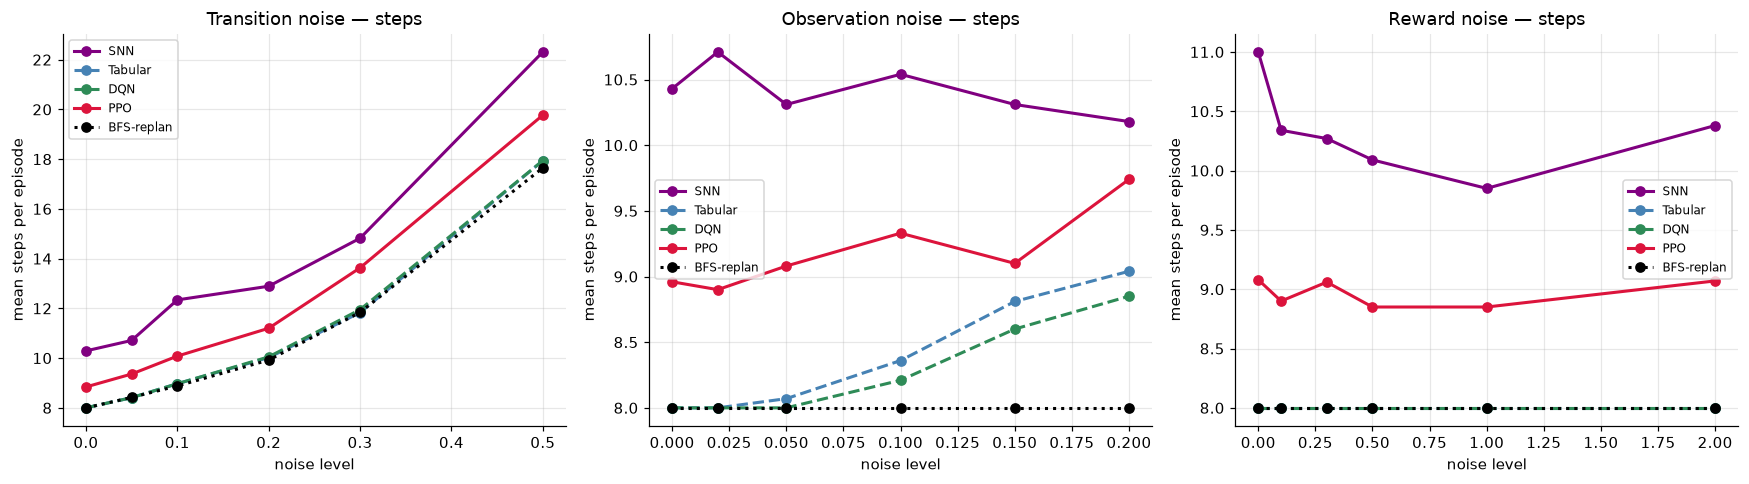

Saved: d:\Research\reward-modulated-spiking-rl\results\figures\noise_robustness_steps.png


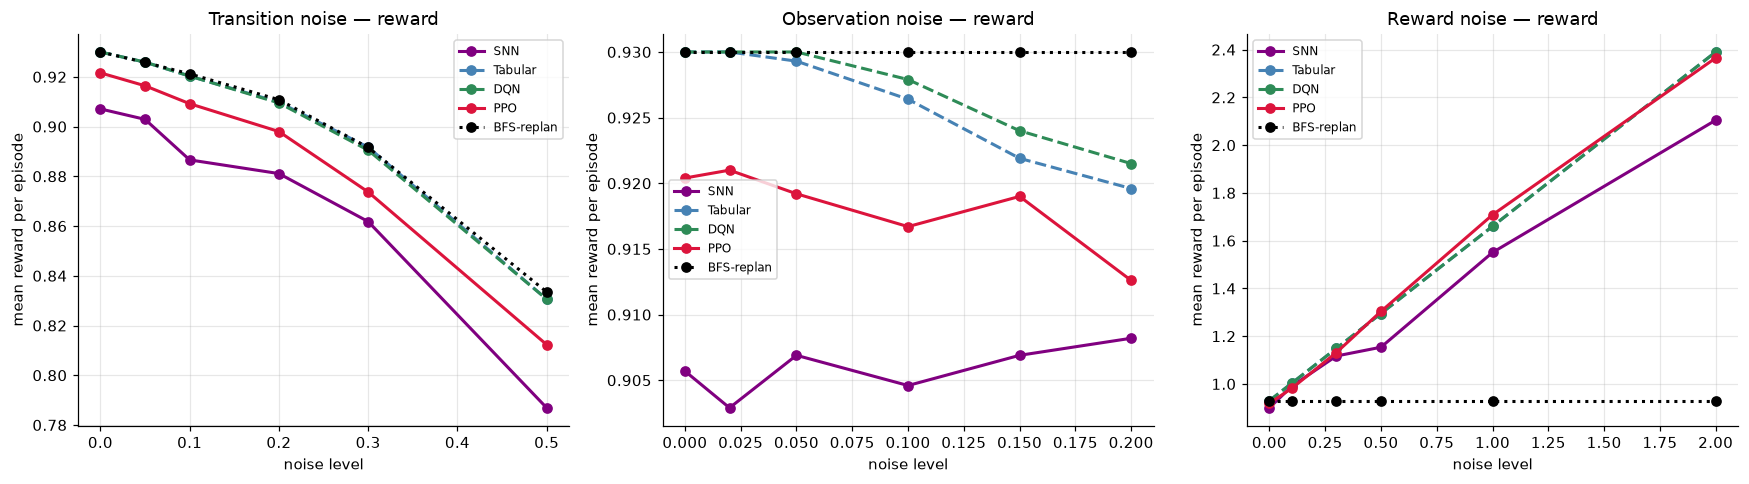

Saved: d:\Research\reward-modulated-spiking-rl\results\figures\noise_robustness_reward.png


In [10]:
agent_colors = {
    "SNN": "purple",
    "Tabular": "steelblue",
    "DQN": "seagreen",
    "PPO": "crimson",
    "BFS-replan": "black",
}

agent_styles = {
    "SNN": "-",
    "Tabular": "--",
    "DQN": "--",
    "PPO": "-",
    "BFS-replan": ":",
}

sweeps = [
    ("Transition noise", transition_levels, transition_results),
    ("Observation noise", observation_levels, observation_results),
    ("Reward noise", reward_levels, reward_results),
]

# --- Figure 1: steps per episode ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (title, levels, results), ax in zip(sweeps, axes):
    for name in results:
        steps = [r["mean_steps"] for r in results[name]]
        ax.plot(levels, steps,
                marker="o", linewidth=2,
                color=agent_colors[name],
                linestyle=agent_styles[name],
                label=name)
    ax.set_xlabel("noise level")
    ax.set_ylabel("mean steps per episode")
    ax.set_title(f"{title} — steps")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "noise_robustness_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'noise_robustness_steps.png'}")

# --- Figure 2: mean reward ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (title, levels, results), ax in zip(sweeps, axes):
    for name in results:
        rewards = [r["mean_reward"] for r in results[name]]
        ax.plot(levels, rewards,
                marker="o", linewidth=2,
                color=agent_colors[name],
                linestyle=agent_styles[name],
                label=name)
    ax.set_xlabel("noise level")
    ax.set_ylabel("mean reward per episode")
    ax.set_title(f"{title} — reward")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "noise_robustness_reward.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'noise_robustness_reward.png'}")

## Summary tables

The tables report mean steps (top) and mean reward (bottom) for each agent
and noise level. The final block summarizes the change in mean steps from
zero noise to maximum noise, along with a flag for whether the change is
meaningful (|Δ| > 0.5 steps, our approximate noise floor for 100 evaluation
episodes).

In [11]:
def print_summary_table(title, levels, results, metric):
    print(f"\n{title} — {metric}")
    print("=" * 90)
    header = f"{'Agent':<14s}" + "".join([f"{l:>10.2f}" for l in levels])
    print(header)
    print("-" * 90)
    for name in results:
        row = f"{name:<14s}"
        for r in results[name]:
            row += f"{r[metric]:>10.3f}"
        print(row)
    print()


print_summary_table("Transition noise", transition_levels, transition_results, "mean_steps")
print_summary_table("Observation noise", observation_levels, observation_results, "mean_steps")
print_summary_table("Reward noise", reward_levels, reward_results, "mean_steps")

print_summary_table("Transition noise", transition_levels, transition_results, "mean_reward")
print_summary_table("Observation noise", observation_levels, observation_results, "mean_reward")


Transition noise — mean_steps
Agent               0.00      0.05      0.10      0.20      0.30      0.50
------------------------------------------------------------------------------------------
SNN               10.290    10.710    12.340    12.890    14.820    22.310
Tabular            8.000     8.410     8.970    10.020    11.830    17.940
DQN                8.000     8.410     8.970    10.050    11.950    17.940
PPO                8.840     9.360    10.080    11.200    13.630    19.770
BFS-replan         8.000     8.420     8.880     9.920    11.840    17.650


Observation noise — mean_steps
Agent               0.00      0.02      0.05      0.10      0.15      0.20
------------------------------------------------------------------------------------------
SNN               10.430    10.710    10.310    10.540    10.310    10.180
Tabular            8.000     8.000     8.070     8.360     8.810     9.040
DQN                8.000     8.000     8.000     8.210     8.600     8.850
PPO 

In [ ]:
# Robustness check: how much does each agent's step count change from
# zero noise to the highest noise level? We report per-agent deltas and
# are careful about what counts as "meaningful". For reward noise, we
# treat all deltas as noise by construction (the policy is unaffected).

def robustness_check(results, levels, name, exclude_from_winner=(), 
                     is_policy_affecting=True):
    print(f"\n{name} — step count change (0.0 → {levels[-1]:.2f})")
    print(f"{'Agent':<14s} {'baseline':>10s} {'final':>8s} "
          f"{'Δ':>9s} {'Δ%':>8s} {'meaningful?':>13s}")
    print("-" * 76)

    rows = []
    for agent in results:
        baseline = results[agent][0]["mean_steps"]
        final = results[agent][-1]["mean_steps"]
        delta = final - baseline
        pct = 100.0 * delta / baseline if baseline > 0 else 0.0
        # Threshold: is the change meaningful? Use 0.5 steps as a rough
        # cutoff, but only count it as "meaningful" if the noise type can
        # actually affect the policy.
        if not is_policy_affecting:
            meaningful = False
        else:
            meaningful = abs(delta) > 0.5
        rows.append((agent, baseline, final, delta, pct, meaningful))

    # Sort by delta ascending (most negative first).
    rows.sort(key=lambda r: r[3])

    for agent, base, final, delta, pct, meaningful in rows:
        marker = "yes" if meaningful else "no"
        print(f"{agent:<14s} {base:>10.2f} {final:>8.2f} "
              f"{delta:>+9.2f} {pct:>+7.1f}% {marker:>13s}")

    # --- Summary: which agents actually changed? ---
    meaningful_agents = [r for r in rows if r[5] and r[0] not in exclude_from_winner]
    flat_agents = [r for r in rows if not r[5] and r[0] not in exclude_from_winner]

    if not is_policy_affecting:
        print("\n  → This noise type does not affect the policy. All deltas")
        print("    reflect evaluation noise only. No robustness conclusion")
        print("    can be drawn here.")
    elif meaningful_agents and flat_agents:
        flat_names = ", ".join(r[0] for r in flat_agents)
        changed_names = ", ".join(f"{r[0]} (+{r[3]:.2f})" for r in meaningful_agents)
        print(f"\n  → {flat_names} show no meaningful change.")
        print(f"    {changed_names} show meaningful step increases.")
    elif not meaningful_agents:
        print(f"\n  → No agent shows a meaningful change in step count.")
    else:
        all_changed = ", ".join(f"{r[0]} (+{r[3]:.2f})" for r in meaningful_agents)
        print(f"\n  → All agents show meaningful changes: {all_changed}")


print("=" * 76)
print("Robustness = change in mean steps from zero noise to maximum noise")
print("=" * 76)

robustness_check(transition_results, transition_levels, "Transition noise")

robustness_check(observation_results, observation_levels, "Observation noise",
                 exclude_from_winner=("BFS-replan",))

robustness_check(reward_results, reward_levels, "Reward noise",
                 exclude_from_winner=("BFS-replan",),
                 is_policy_affecting=False)

Robustness = change in mean steps from zero noise to maximum noise

Transition noise — step count change (0.0 → 0.50)
Agent            baseline    final         Δ       Δ%   meaningful?
----------------------------------------------------------------------------
BFS-replan           8.00    17.65     +9.65  +120.6%           yes
Tabular              8.00    17.94     +9.94  +124.3%           yes
DQN                  8.00    17.94     +9.94  +124.3%           yes
PPO                  8.84    19.77    +10.93  +123.6%           yes
SNN                 10.29    22.31    +12.02  +116.8%           yes

  → All agents show meaningful changes: BFS-replan (+9.65), Tabular (+9.94), DQN (+9.94), PPO (+10.93), SNN (+12.02)

Observation noise — step count change (0.0 → 0.20)
Agent            baseline    final         Δ       Δ%   meaningful?
----------------------------------------------------------------------------
SNN                 10.43    10.18     -0.25    -2.4%            no
BFS-replan    

## Interpretation

Success rate is 1.0 for every agent at every noise level. The task is
solvable by all agents across the noise ranges we tested. "Which agent is
more robust" must therefore be answered by looking at **step efficiency**,
not success.

A change in mean steps is treated as meaningful only if it exceeds 0.5
steps, which is our approximate noise floor for 100 evaluation episodes.

### Transition noise

All agents are affected by transition noise. Each agent's step count
roughly doubles from noise 0.0 to 0.5:

| Agent | steps (0.0) | steps (0.5) | change |
|-------|-------------|-------------|--------|
| BFS-replan | 8.00 | 17.65 | +120.6% |
| Tabular | 8.00 | 17.94 | +124.3% |
| DQN | 8.00 | 17.94 | +124.3% |
| PPO | 8.84 | 19.77 | +123.6% |
| SNN | 10.29 | 22.31 | +116.8% |

On a percentage basis, all agents are affected similarly (117–124%). The
SNN's absolute increase is the largest only because it starts from a
longer baseline path. **The SNN's stochastic policy does not confer
robustness to action-execution noise.** Slips force longer trajectories
regardless of the policy's readout mechanism.

### Observation noise

Here the SNN is meaningfully more robust:

| Agent | steps (0.00) | steps (0.20) | change |
|-------|--------------|--------------|--------|
| SNN | 10.43 | 10.18 | −0.25 (sightly decreases) |
| BFS-replan | 8.00 | 8.00 | +0.00 (ignores observation noise) |
| PPO | 8.96 | 9.74 | +0.78 (increases) |
| DQN | 8.00 | 8.85 | +0.85 (increases) |
| Tabular | 8.00 | 9.04 | +1.04 (increases) |

The SNN's step count is flat across σ ∈ [0.0, 0.20], while every
conventional baseline's increases by 0.78–1.04 steps. The plausible
mechanism is that the SNN's readout is a 5-step accumulation of output
spikes followed by softmax sampling — a low-pass filter. Brief input
perturbations do not change the accumulated spike count enough to change
the sampled action. The baselines react to each noisy observation.

BFS-replan is not a fair comparison in this sweep (it uses the true
internal state by construction), so it should be read as a reference, not
a competitor.

### Reward noise

Reward noise is a non-finding. It perturbs the reward signal returned by
the environment but not the observations the agent acts on. Since we do
not retrain, the policy is unaffected. All observed deltas are within
evaluation noise, and no robustness conclusion can be drawn.

### Overall

The stochasticity hypothesis is **partially supported**:

- **Observation noise:** SNN more robust. Conventional baselines degrade
  by ~10%; SNN is flat.
- **Transition noise:** All agents affected similarly. Only a little advantage for
  the SNN observed
- **Reward noise:** Not applicable to policy behavior.

The result is more nuanced than a simple "stochastic is better" claim.
Different noise types interact differently with the policy's source of
randomness. The observation-noise advantage is consistent with a
low-pass-filter interpretation of spike-count readout, which specifically
helps against short-timescale input perturbations but not against
systematic action-execution failures.